# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [1]:
import numpy as np
import pandas as pd

class MyBinaryLogisticRegression:
    def __init__(self, regularization='l2', lambda_reg=0.1, max_iter=1000, learning_rate=0.01, tol=1e-6):
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        self.coefs_ = None
        self.feature_names_in_ = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict_prob(self, X):
        return self.sigmoid(np.dot(X, self.coefs_))

    def predict(self, X):
        return (self.predict_prob(X) >= 0.5).astype(int)

    def loss(self, X, y):
        m = X.shape[0]
        predictions = self.predict_prob(X)
        log_loss = -(y * np.log(predictions) + (1 - y) * np.log(1 - predictions)).mean()
        
        if self.regularization == 'l2':
            reg_loss = self.lambda_reg * np.sum(self.coefs_ ** 2) / 2
        elif self.regularization == 'l1':
            reg_loss = self.lambda_reg * np.sum(np.abs(self.coefs_))
        elif self.regularization == 'l1l2':
            reg_loss = self.lambda_reg * (np.sum(np.abs(self.coefs_)) + np.sum(self.coefs_ ** 2) / 2)
        else:
            reg_loss = 0
        
        return log_loss + reg_loss

    def gradient(self, X, y):
        m = X.shape[0]
        predictions = self.predict_prob(X)
        error = predictions - y
        grad_w = np.dot(X.T, error) / m
        
        if self.regularization == 'l2':
            grad_w += self.lambda_reg * self.coefs_
        elif self.regularization == 'l1':
            grad_w += self.lambda_reg * np.sign(self.coefs_)
        elif self.regularization == 'l1l2':
            grad_w += self.lambda_reg * (np.sign(self.coefs_) + self.coefs_)
        
        return grad_w

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, method='gradient_descent'):
        self.coefs_ = np.zeros(X.shape[1])
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        
        if method == 'gradient_descent':
            self._gradient_descent(X, y)
        elif method == 'stochastic_gradient_descent':
            self._stochastic_gradient_descent(X, y)

    def _gradient_descent(self, X, y):
        for i in range(self.max_iter):
            grad_w = self.gradient(X, y)
            self.coefs_ -= self.learning_rate * grad_w
            
            if np.linalg.norm(grad_w) < self.tol:
                break

    def _stochastic_gradient_descent(self, X, y):
        m = X.shape[0]
        for i in range(self.max_iter):
            for j in range(m):
                idx = np.random.randint(0, m)
                X_batch = X[idx:idx+1]
                y_batch = y[idx:idx+1]
                
                grad_w = self.gradient(X_batch, y_batch)
                self.coefs_ -= self.learning_rate * grad_w
            
            if np.linalg.norm(grad_w) < self.tol:
                break

    def _hessian(self, X, y):
        m = X.shape[0]
        predictions = self.predict_prob(X)
        diag = predictions * (1 - predictions)
        H = np.dot(X.T * diag, X) / m
        return H

    def score(self, X: np.array, y: np.array):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y)
        return accuracy


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns

data_init = pd.read_csv("penguins_binary_classification.csv").dropna()
data = data_init.copy()

data_init.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [3]:
data['species'] = data['species'].map({'Adelie': 0, 'Gentoo': 1})

In [4]:
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data[num_features] = (data[num_features] - data[num_features].mean()) / data[num_features].std()

In [5]:
target_means = data.groupby('island')['species'].mean()
data['island'] = data['island'].map(target_means)

In [6]:
X = data.drop(columns=['species'])
y = data['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = MyBinaryLogisticRegression(regularization='l2', learning_rate=0.01, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 1.0000


In [23]:
optimizers = ['gradient_descent', 'stochastic_gradient_descent']
regularizations = ['l1l2', 'l1', 'l2']
results = []

for optimizer in optimizers:
    for regularization in regularizations:
        model = MyBinaryLogisticRegression(
            regularization=regularization,
            learning_rate=0.0001,
            max_iter=100
        )
        model.fit(X_train, y_train, method=optimizer)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        results.append({
            'Optimizer': optimizer,
            'Regularization': regularization,
            'F1-Score': f"{f1:.4f}"
        })

results

[{'Optimizer': 'gradient_descent',
  'Regularization': 'l1l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'gradient_descent',
  'Regularization': 'l1',
  'F1-Score': '1.0000'},
 {'Optimizer': 'gradient_descent',
  'Regularization': 'l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l1l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l1',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l2',
  'F1-Score': '1.0000'}]

In [10]:
data['island'] = data_init['island']
data = pd.get_dummies(data, columns=['island'])

data

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Biscoe,island_Dream,island_Torgersen
0,0,-0.693460,0.925728,-1.407424,-0.679559,2007,False,False,True
1,0,-0.616472,0.280057,-1.075153,-0.619745,2007,False,False,True
2,0,-0.462494,0.578059,-0.477064,-1.277693,2007,False,False,True
3,0,-1.155393,1.223729,-0.609973,-1.038439,2007,False,False,True
4,0,-0.654966,1.869400,-0.809336,-0.799186,2007,False,False,True
...,...,...,...,...,...,...,...,...,...
269,1,0.865561,-1.557622,0.785567,0.726056,2009,True,False,False
270,1,0.788572,-1.259620,0.852022,0.636336,2009,True,False,False
271,1,1.481471,-0.564282,1.317202,1.712977,2009,True,False,False
272,1,0.480618,-1.011285,0.652659,1.055030,2009,True,False,False


In [11]:
X = data.drop(columns=['species'])
y = data['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
optimizers = ['gradient_descent', 'stochastic_gradient_descent']
regularizations = ['l1l2', 'l1', 'l2']
results = []

for optimizer in optimizers:
    for regularization in regularizations:
        model = MyBinaryLogisticRegression(
            regularization=regularization,
            learning_rate=0.01,
            max_iter=100
        )
        model.fit(X_train, y_train, method=optimizer)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        results.append({
            'Optimizer': optimizer,
            'Regularization': regularization,
            'F1-Score': f"{f1:.4f}"
        })

results

[{'Optimizer': 'gradient_descent',
  'Regularization': 'l1l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'gradient_descent',
  'Regularization': 'l1',
  'F1-Score': '1.0000'},
 {'Optimizer': 'gradient_descent',
  'Regularization': 'l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l1l2',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l1',
  'F1-Score': '1.0000'},
 {'Optimizer': 'stochastic_gradient_descent',
  'Regularization': 'l2',
  'F1-Score': '1.0000'}]

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

Функция потерь:
$$
ln \mathbb P(D|\omega) = \sum_{i = 1}^{N}\sum_{j = 1}^M y_{ij}ln\mathbb P(C_j|x_i).
$$
$$
\frac{\partial \mathbb P(C_j|x_i)}{\partial w_{kz}} = x_{iz}\bigg[ \delta^{k}_{j}P(C_j|x_i)(1-P(C_j|x_i)) - (1-\delta^{k}_{j}) P(C_j|x_i) P(C_k|x_i)\bigg]
$$
градиент:
$$
\frac{\partial ln \mathbb P(D|\omega)}{\partial w_{kz}} = \sum_{i = 1}^{N}\sum_{j = 1}^M y_{ij}\frac{1}{\mathbb P(C_j|x_i)}\frac{\partial \mathbb P(C_j|x_i)}{\partial w_{kz}} = \sum_{i = 1}^{N}\sum_{j = 1}^M y_{ij} x_{iz}\bigg[ \delta^{k}_{j}(1-P(C_j|x_i)) - (1-\delta^{k}_{j})P(C_k|x_i)\bigg]
$$
$$
= \sum_{i = 1}^{N}y_{ik} x_{iz} - \sum_{i = 1}^{N}\sum_{j = 1}^M y_{ij} x_{iz}\bigg[ P(C_k|x_i)\bigg] = \sum_{i = 1}^{N}x_{iz} (y_{ik} - P(C_k|x_i)\sum_{j = 1}^M y_{ij}) = \bigg[\sum_{j = 1}^M y_{ij} =1\bigg] = \sum_{i = 1}^{N}x_{iz} (y_{ik} - P(C_k|x_i))
$$

гессиан:
$$
\frac{\partial^2 ln \mathbb P(D|\omega)}{\partial w_{pw}^T \partial w_{kz}} = -\sum_{i = 1}^{N}x_{iz} x_{iw}\bigg[  \frac{\partial \mathbb P(C_k|x_i)}{\partial w_{pw}}  \bigg] = 
$$
$$
=-\sum_{i = 1}^{N}x_{iz} x_{iw}\bigg[  \delta^{k}_{p}P(C_k|x_i)(1-P(C_k|x_i)) - (1-\delta^{p}_{k}) P(C_k|x_i) P(C_p|x_i)\bigg]
$$
$$
=-\sum_{i = 1}^{N}x_{iz} x_{iw}\bigg[  \delta^{k}_{p}P(C_k|x_i) - P(C_k|x_i) P(C_p|x_i)\bigg] = -\sum_{i = 1}^{N}x_{iz} x_{iw}P(C_k|x_i)\bigg[  \delta^{k}_{p} - P(C_p|x_i)\bigg]
$$

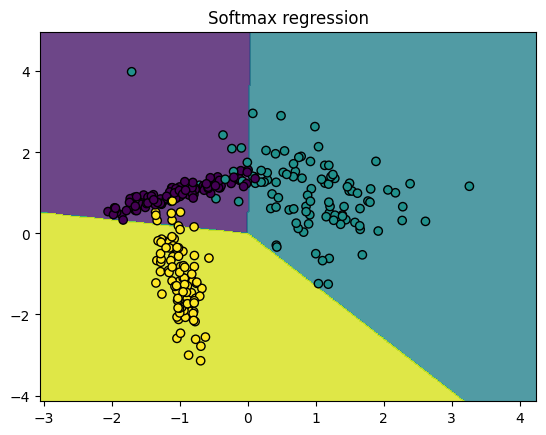

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

N = 300 
M = 3
X, y = make_classification(n_samples=N, n_features=2, n_classes=M, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

y_one_hot = np.eye(M)[y]

omega = np.random.randn(M, X.shape[1])

def softmax(X, omega):
    z = np.dot(X, omega.T)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def loss(X, y_one_hot, omega):
    P = softmax(X, omega)
    return -np.sum(y_one_hot * np.log(P))

def gradient(X, y_one_hot, omega):
    P = softmax(X, omega)
    return np.dot((P - y_one_hot).T, X)

learning_rate = 0.1
epochs = 1000

for epoch in range(epochs):
    grad = gradient(X, y_one_hot, omega)
    omega -= learning_rate * grad

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.argmax(softmax(np.c_[xx.ravel(), yy.ravel()], omega), axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title('Softmax regression')
plt.show()
